In [1]:
import json
from pathlib import Path
from typing import List
import os
def load_exercises_from_json(file_path: Path) -> List[dict]:
    exercises = []
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        exercises = data.get('exercises', [])
    return exercises
EXAMS_DIR = Path("../data/dzexams/maths/bac-blanc/bac-blanc-results")  # Update this path to your exams directory
all_exercises = []
for exam in os.listdir(EXAMS_DIR):
    if exam.endswith(".json"):
        exam_path = EXAMS_DIR / exam
        exercises = load_exercises_from_json(exam_path)
        all_exercises.extend(exercises)
print(f"Total exercises loaded: {len(all_exercises)}")

Total exercises loaded: 139


In [2]:
print("Sample exercise:")
all_exercises[1]

Sample exercise:


{'id': 'e5f6a7b8-c9d0-1e2f-3a4b-5c6d7e8f9a0b',
 'exam_id': '7fb35b7d-55bb-4bbf-a95e-4b638be3a8e3',
 'number': 2,
 'title': 'التمرين الثاني',
 'statement': 'نعتبر المتتالية $(u_n)$ المعرفة بـ : $u_0 = 2$ ومن أجل كل عدد طبيعي $n$ ، $u_{n+1} = \\frac{u_n}{u_n + 2}$ .',
 'topic': 'suites',
 'concepts': ['suites_numeriques',
  'suites_recurrentes',
  'convergence',
  'suites_geometriques',
  'raisonnement_par_recurrence',
  'limites'],
 'difficulty': 'medium',
 'marks': None,
 'has_figure': False,
 'source_page': 1,
 'solution': None,
 'metadata': {},
 'parts': [{'id': 'f6a7b8c9-d0e1-2f3a-4b5c-6d7e8f9a0b1c',
   'exercise_id': 'e5f6a7b8-c9d0-1e2f-3a4b-5c6d7e8f9a0b',
   'label': '1',
   'sub_label': None,
   'statement': 'احسب $u_1$ ، $u_2$ ، $u_3$ .',
   'marks': None,
   'depends_on': [],
   'solution': None,
   'ordering': 1,
   'metadata': {}},
  {'id': 'a7b8c9d0-e1f2-3a4b-5c6d-7e8f9a0b1c2d',
   'exercise_id': 'e5f6a7b8-c9d0-1e2f-3a4b-5c6d7e8f9a0b',
   'label': '2',
   'sub_label': 'أ',
 

Displaying 1 figure(s) from 2022.pdf, Page 2


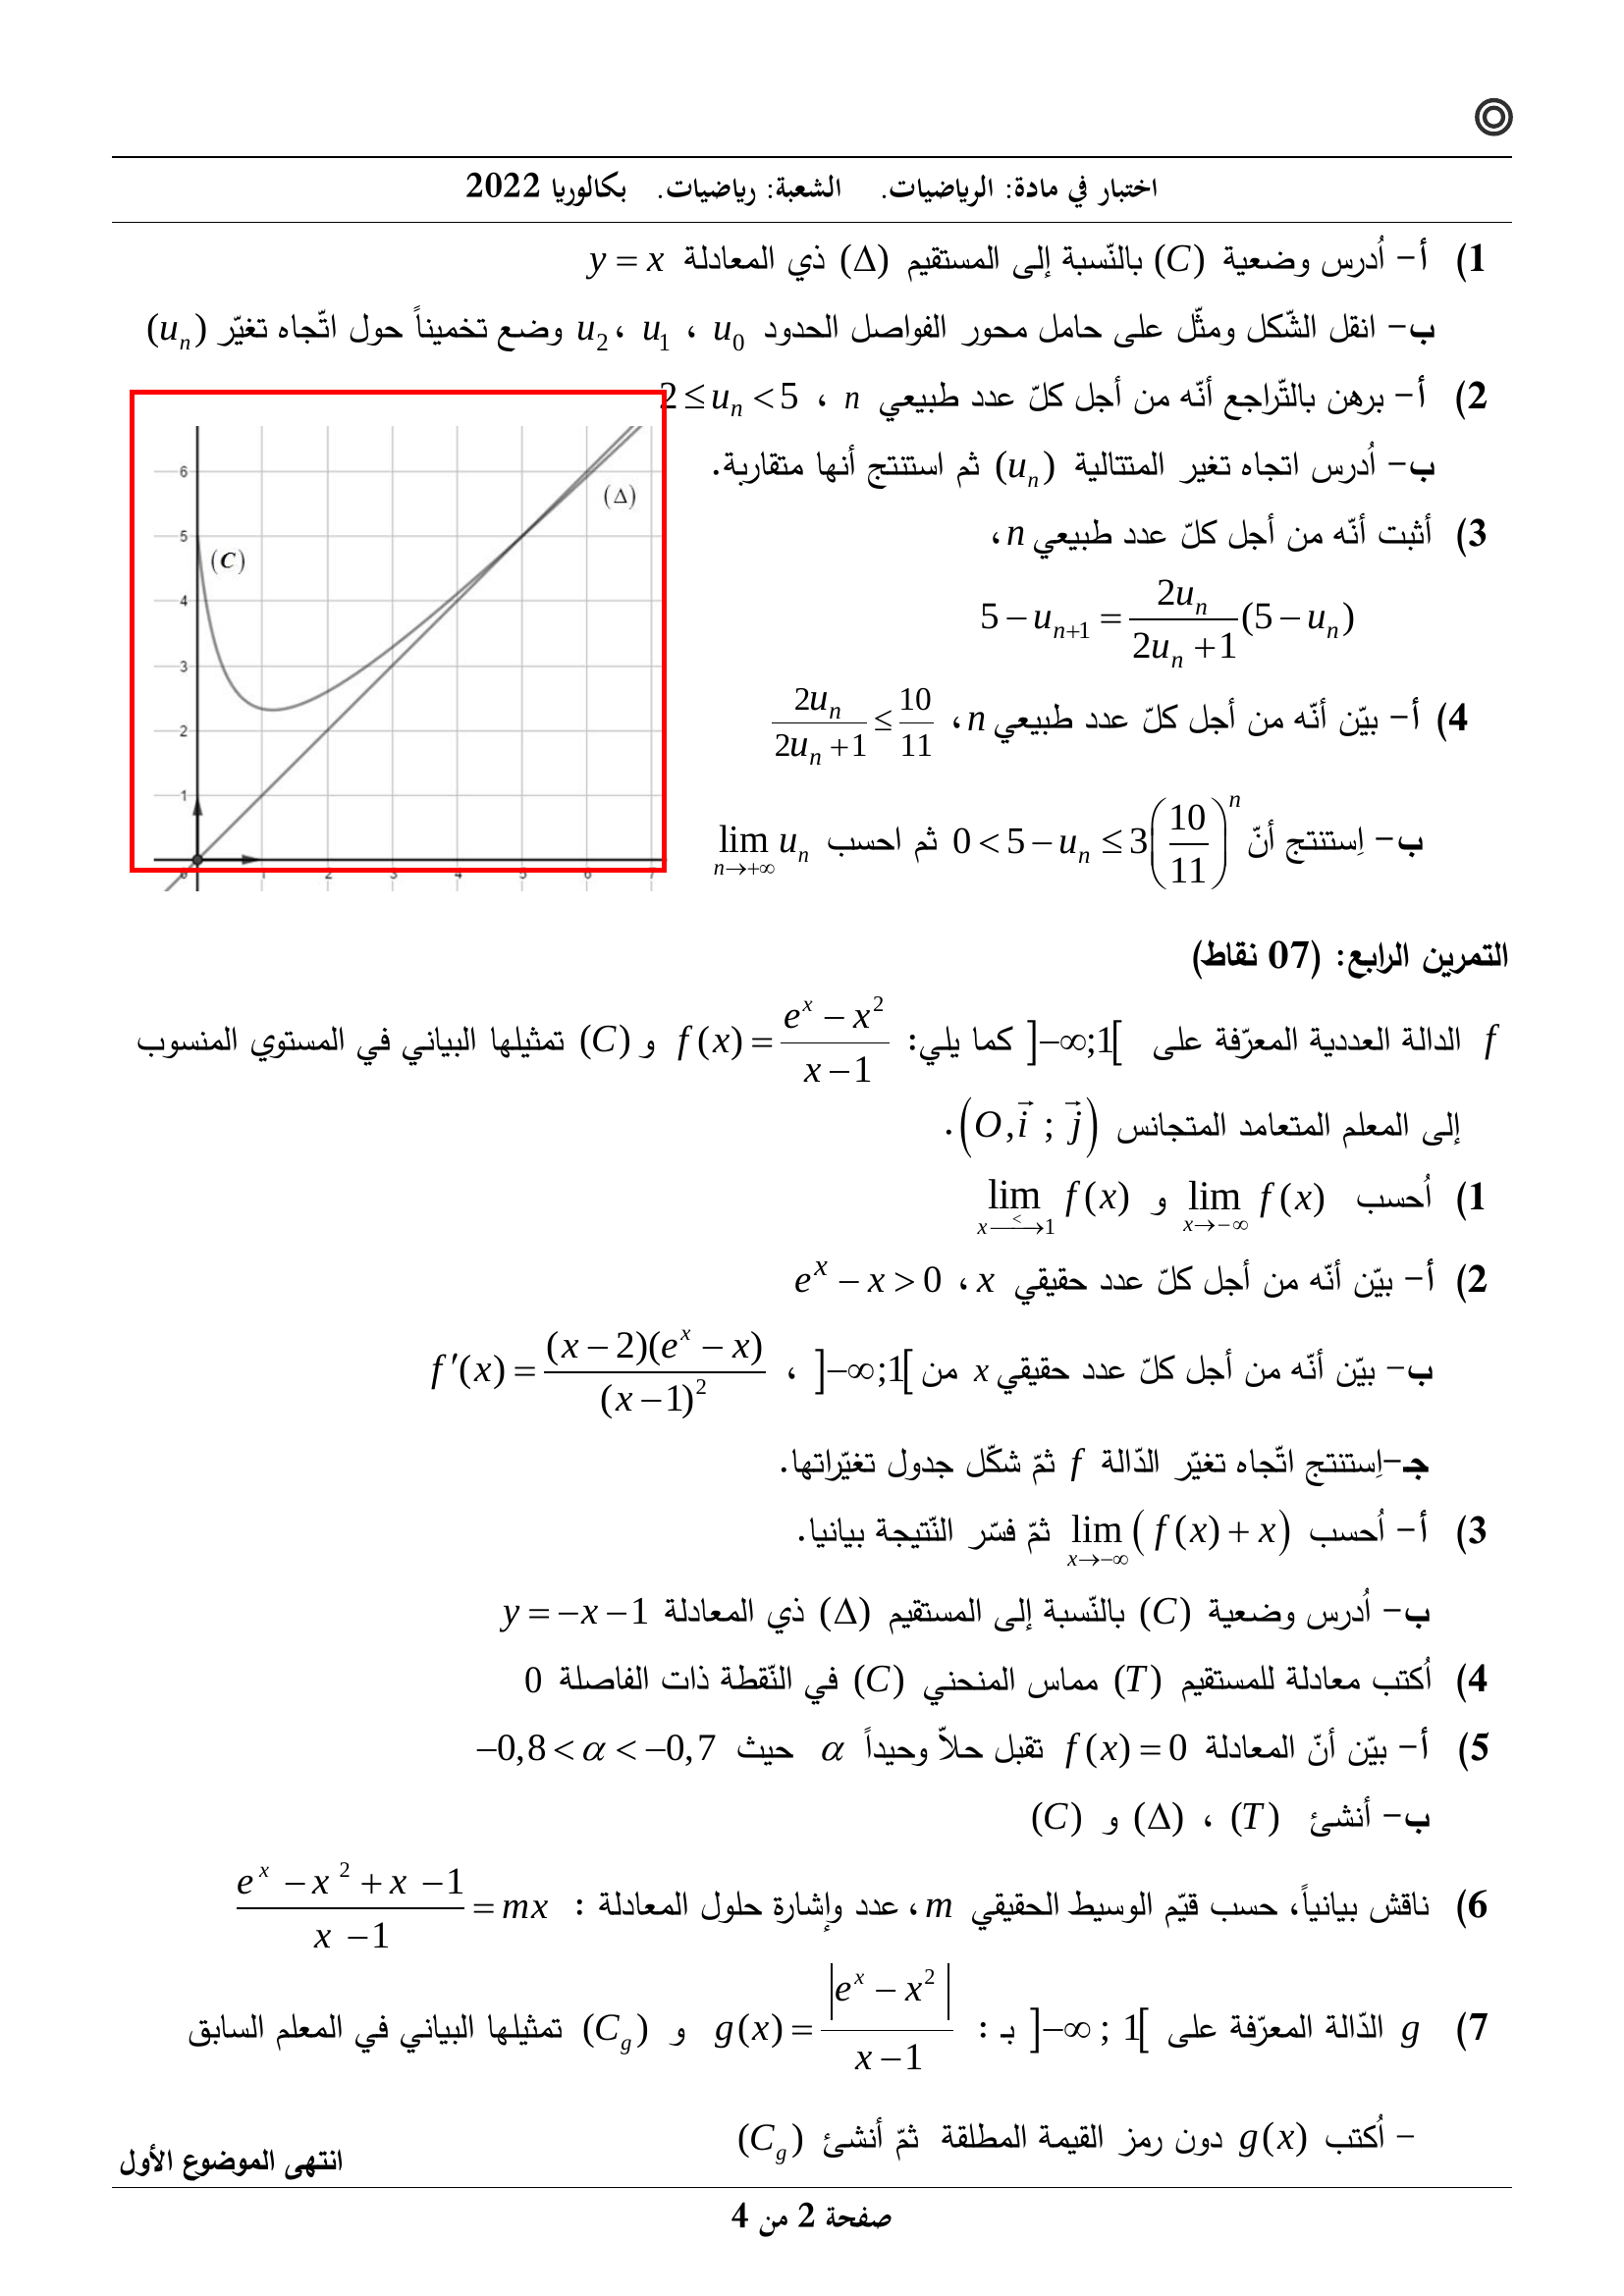

Displaying 1 figure(s) from 2022.pdf, Page 7


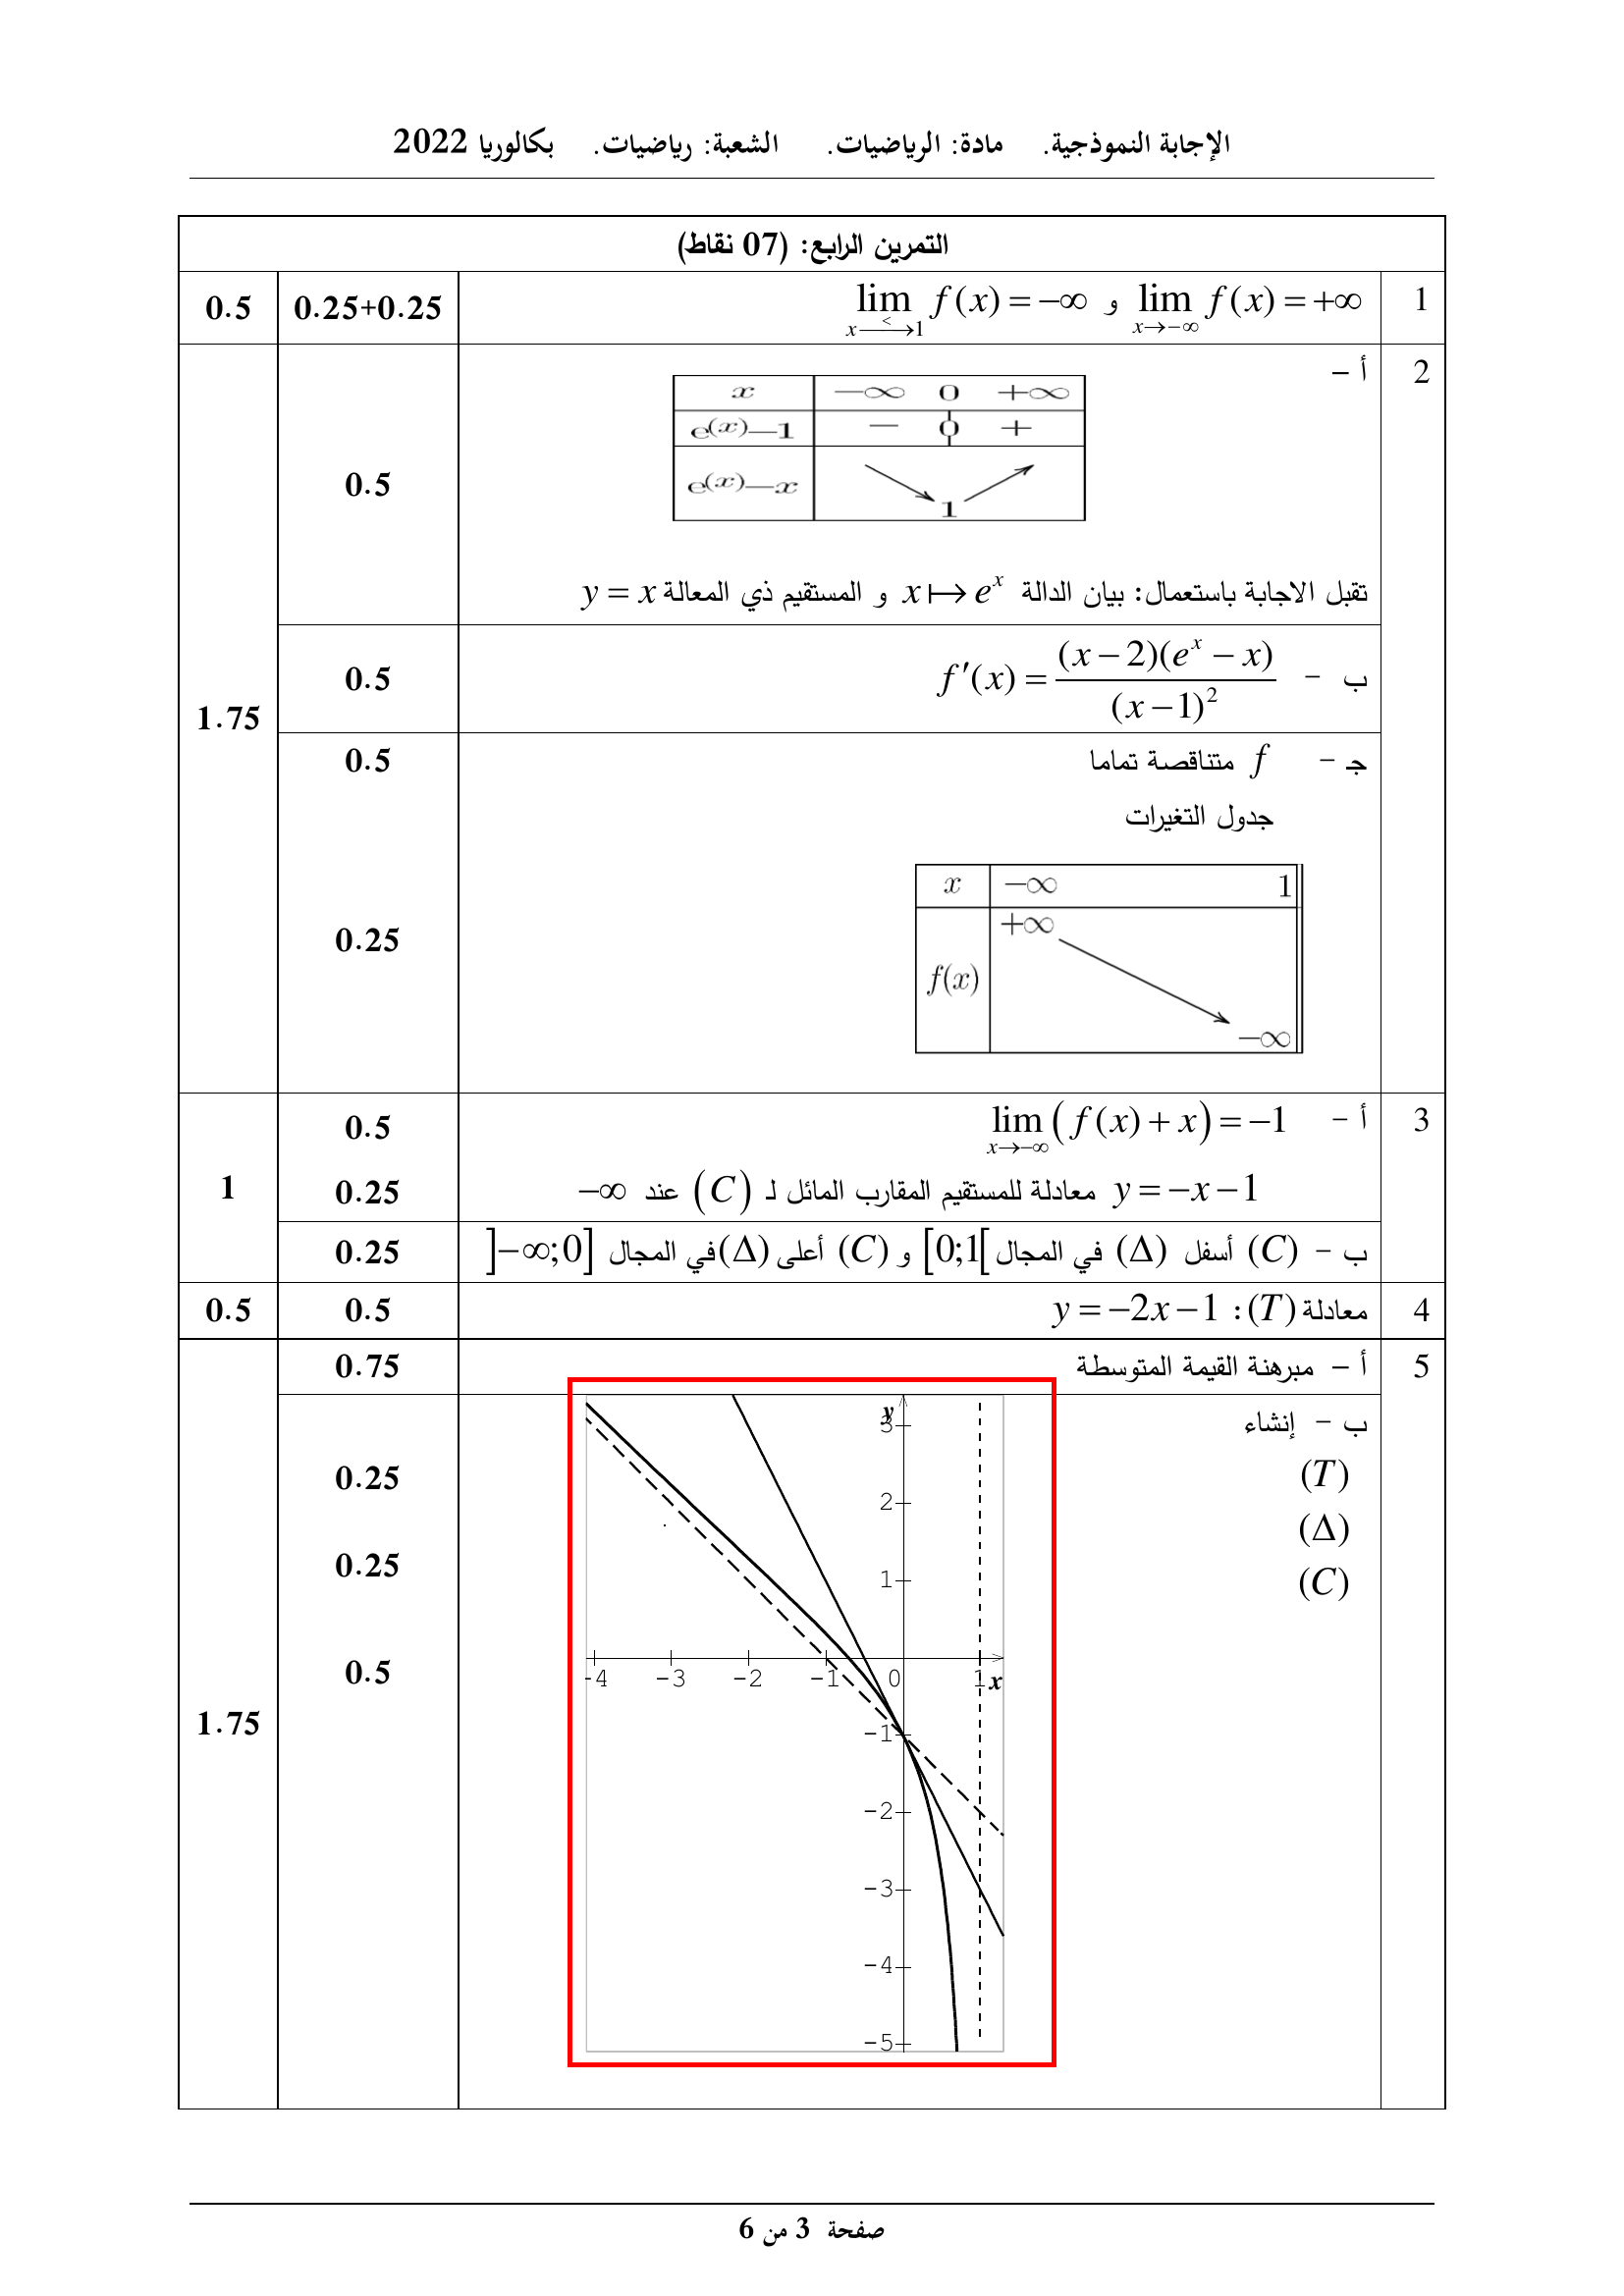

Displaying 1 figure(s) from 2023.pdf, Page 1


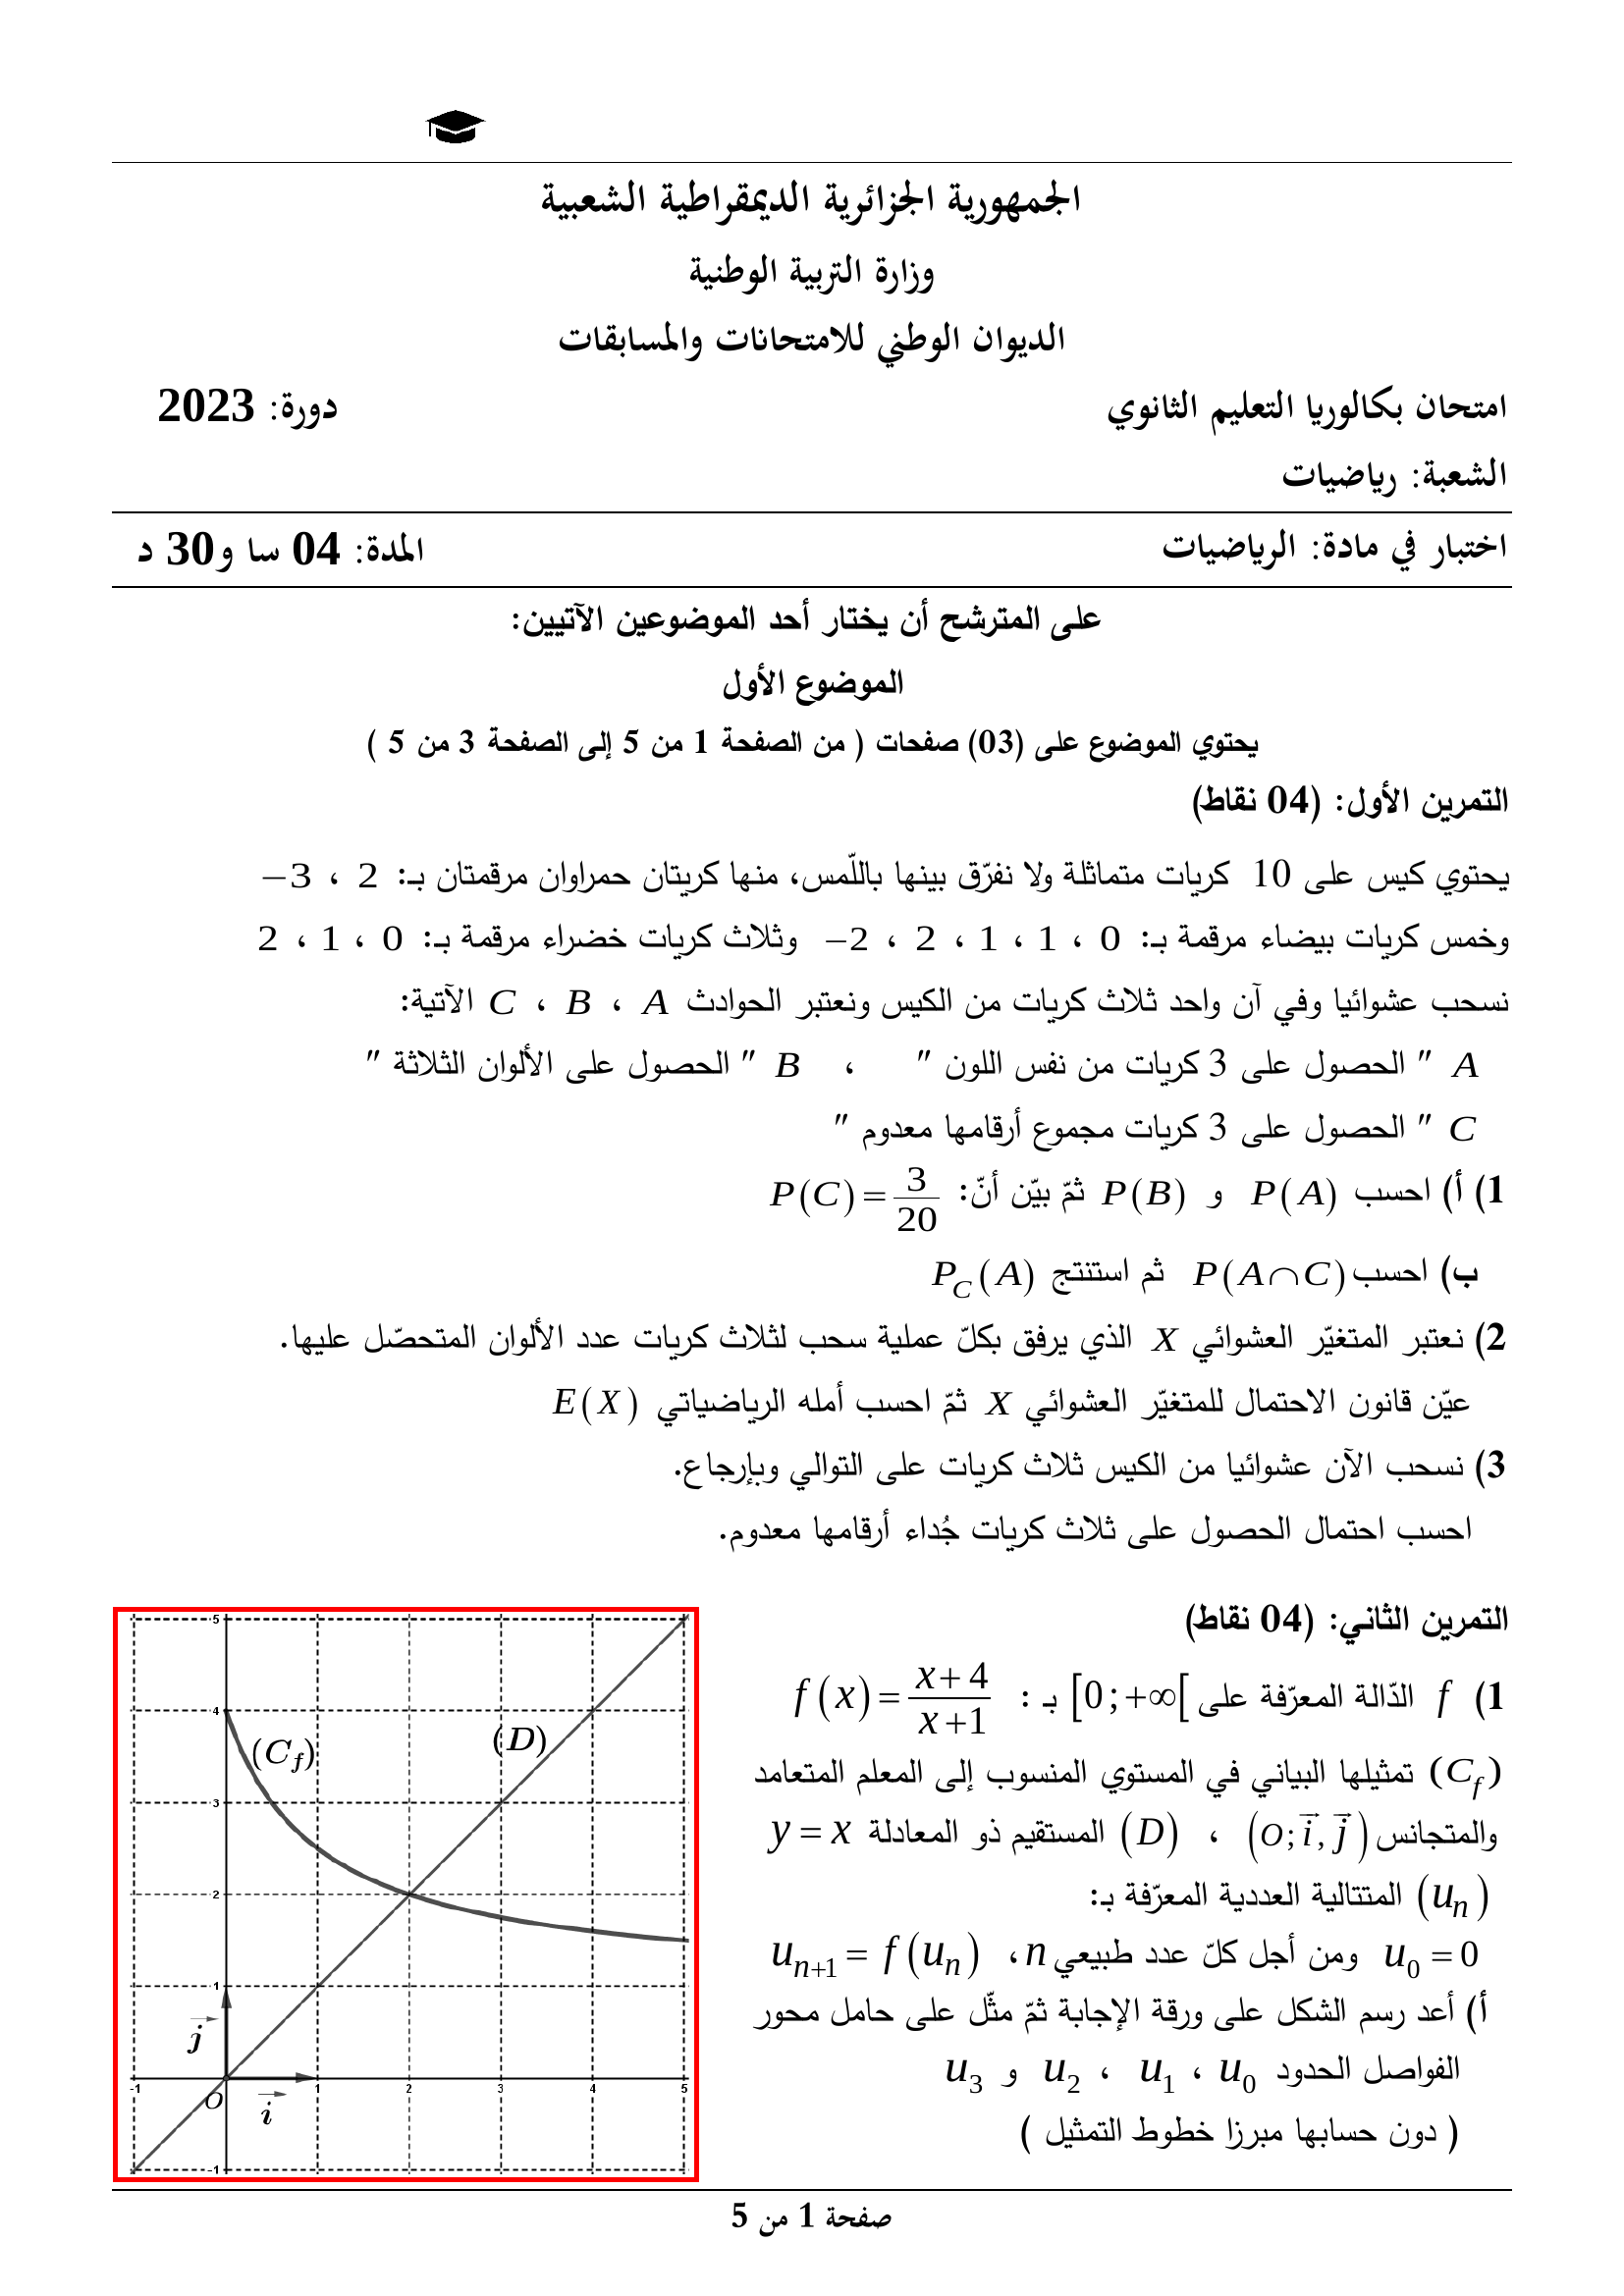

Displaying 1 figure(s) from 2023.pdf, Page 9


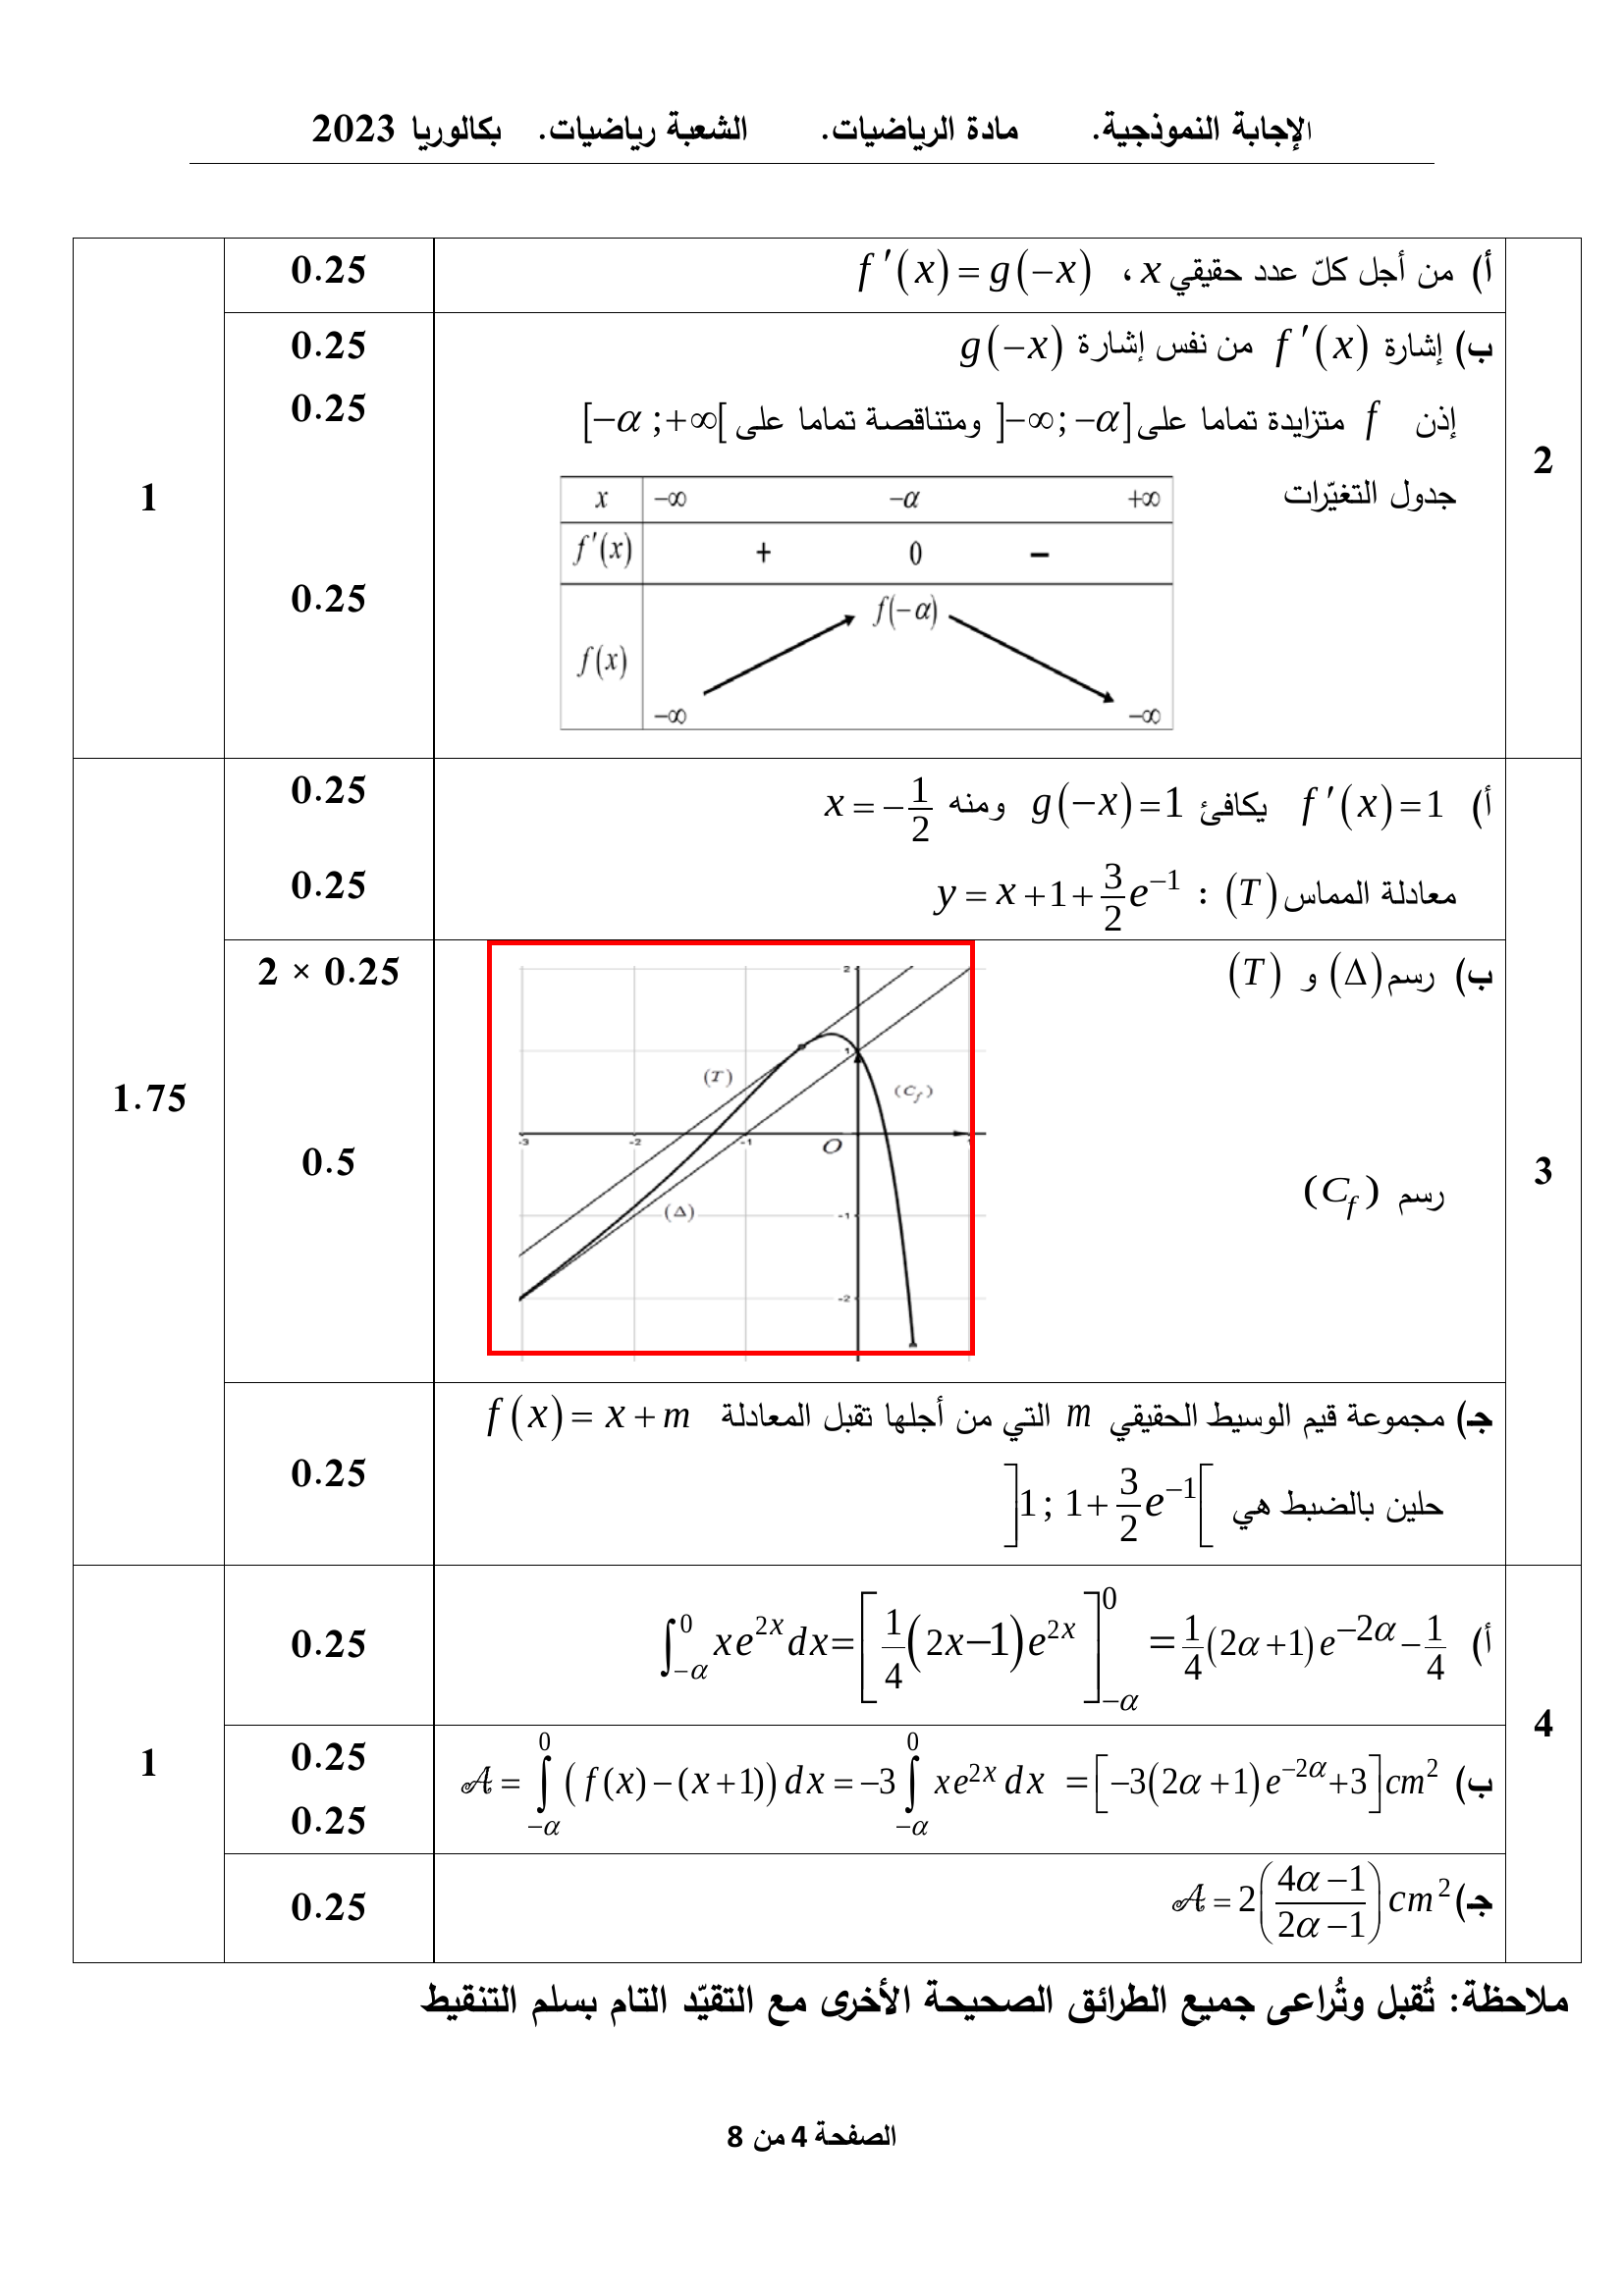

Displaying 1 figure(s) from 2013.pdf, Page 12


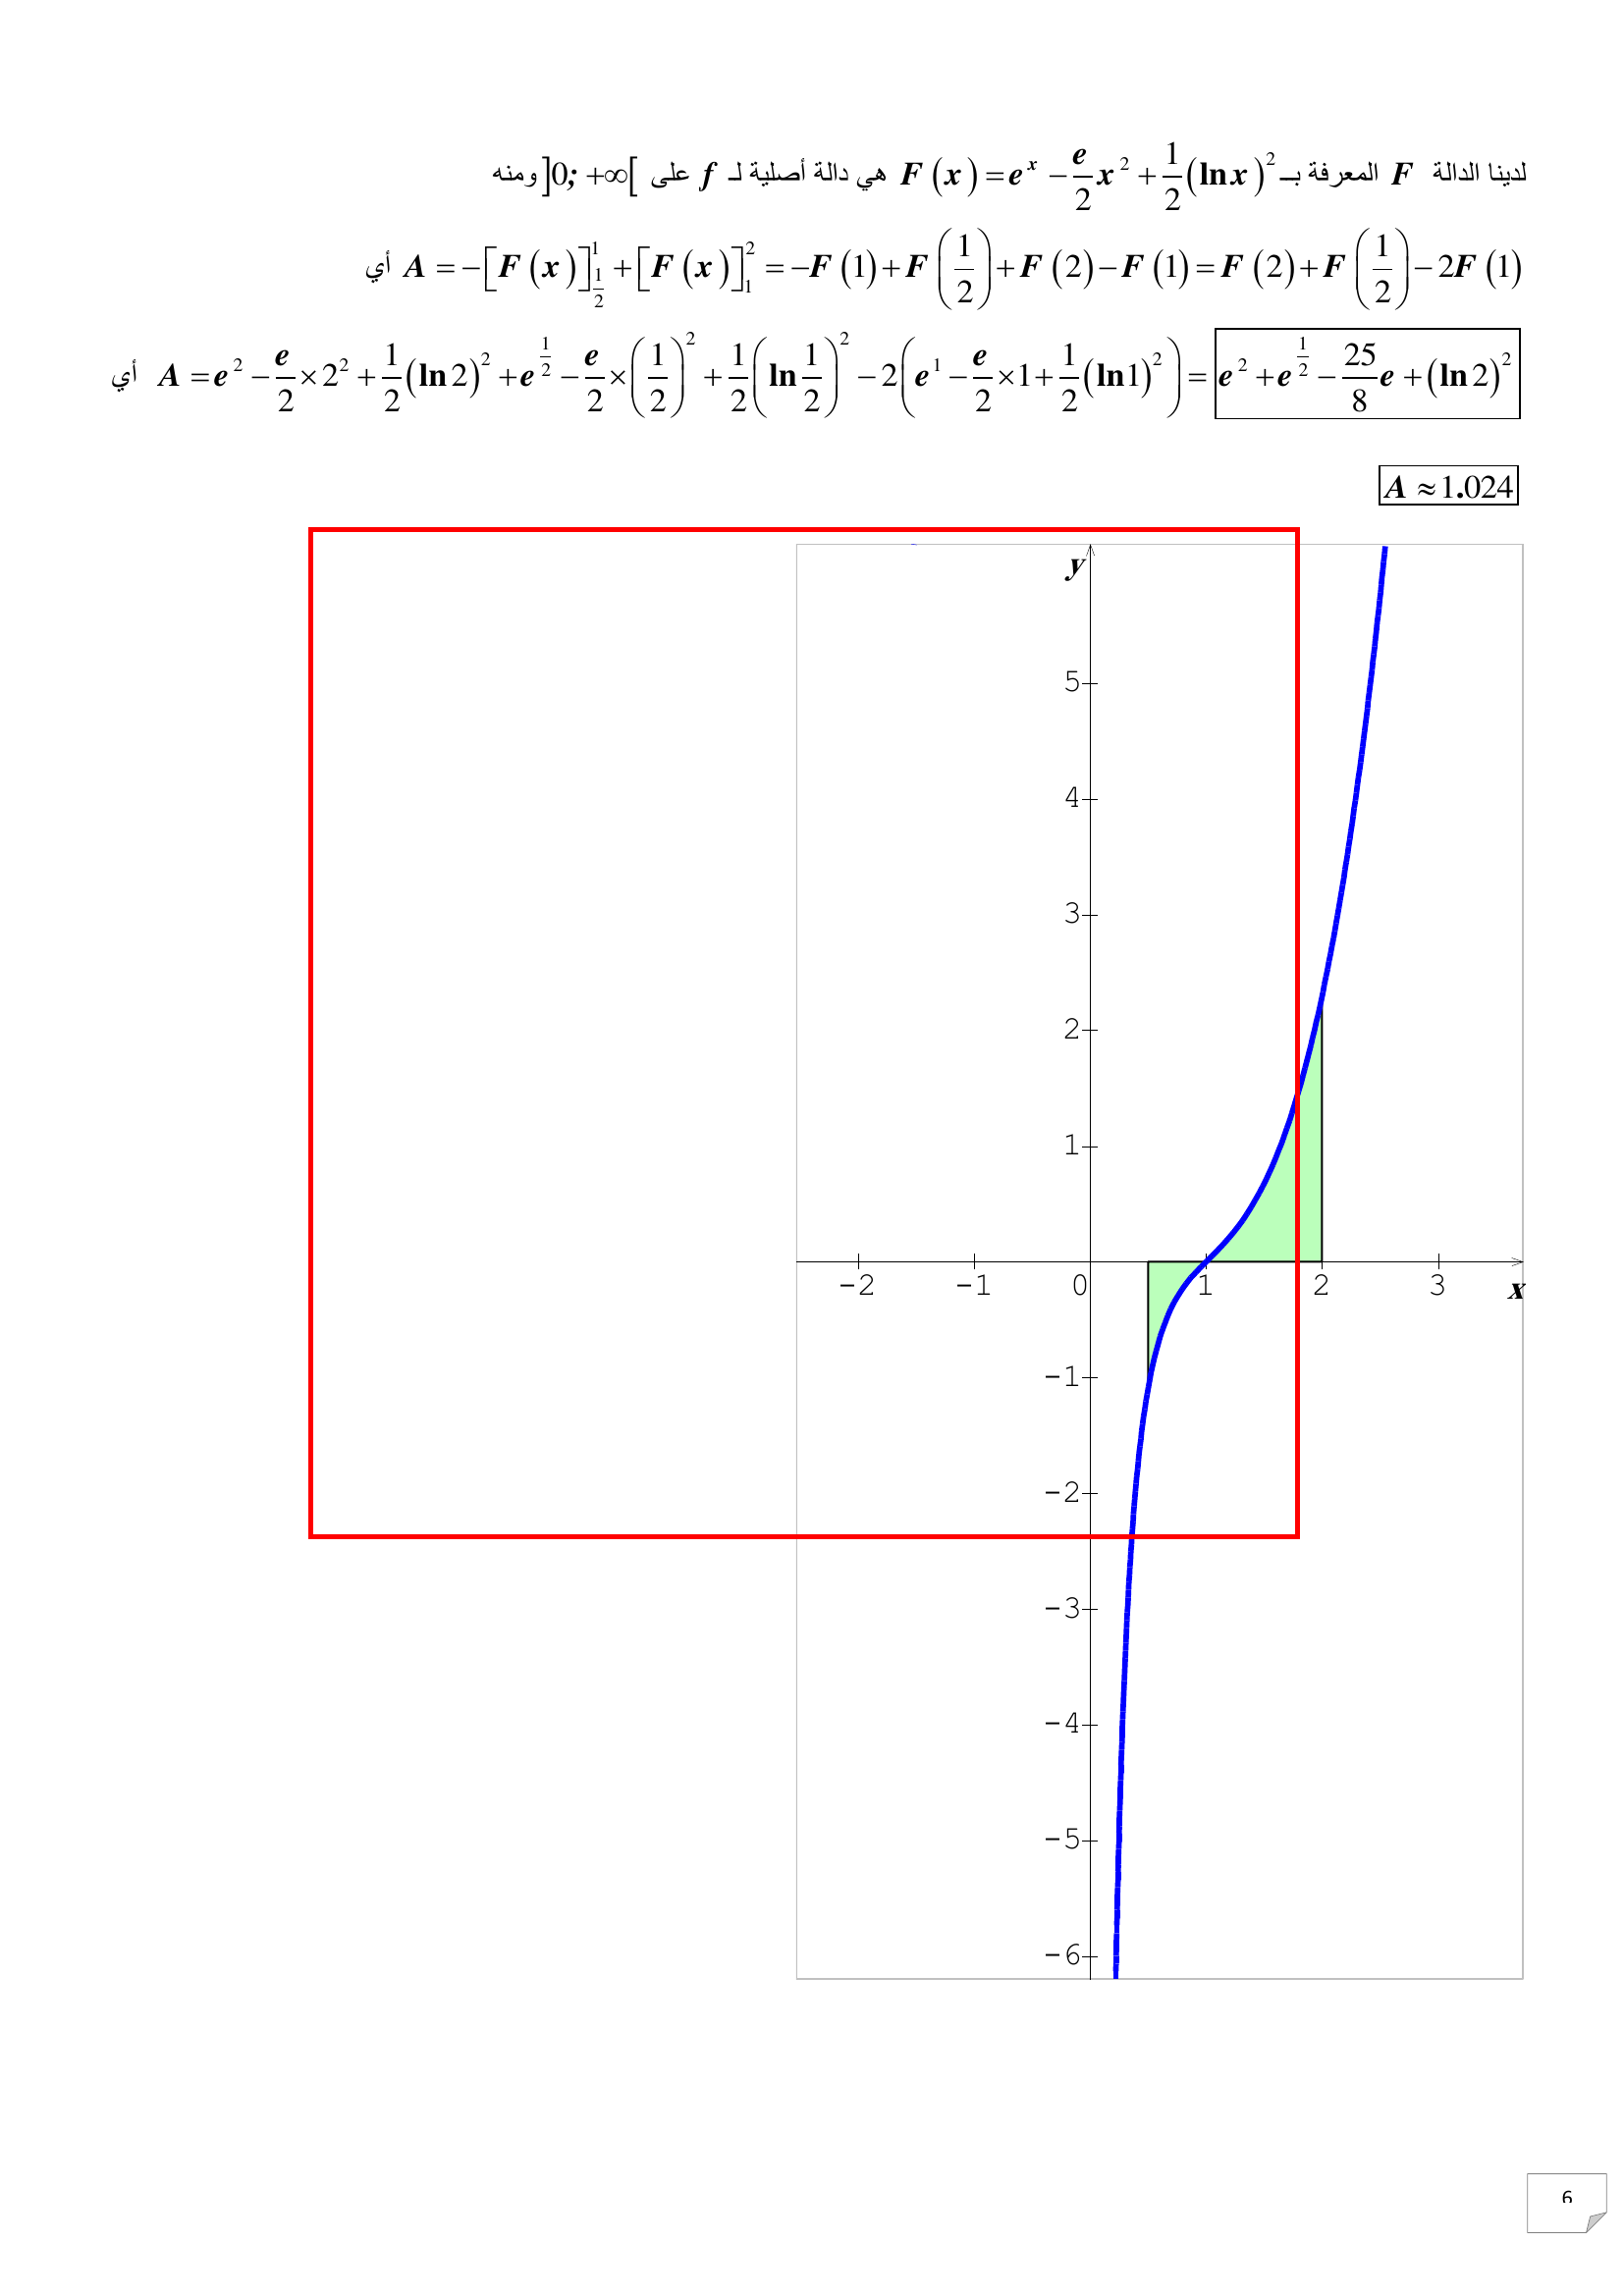

Displaying 1 figure(s) from 2013.pdf, Page 18


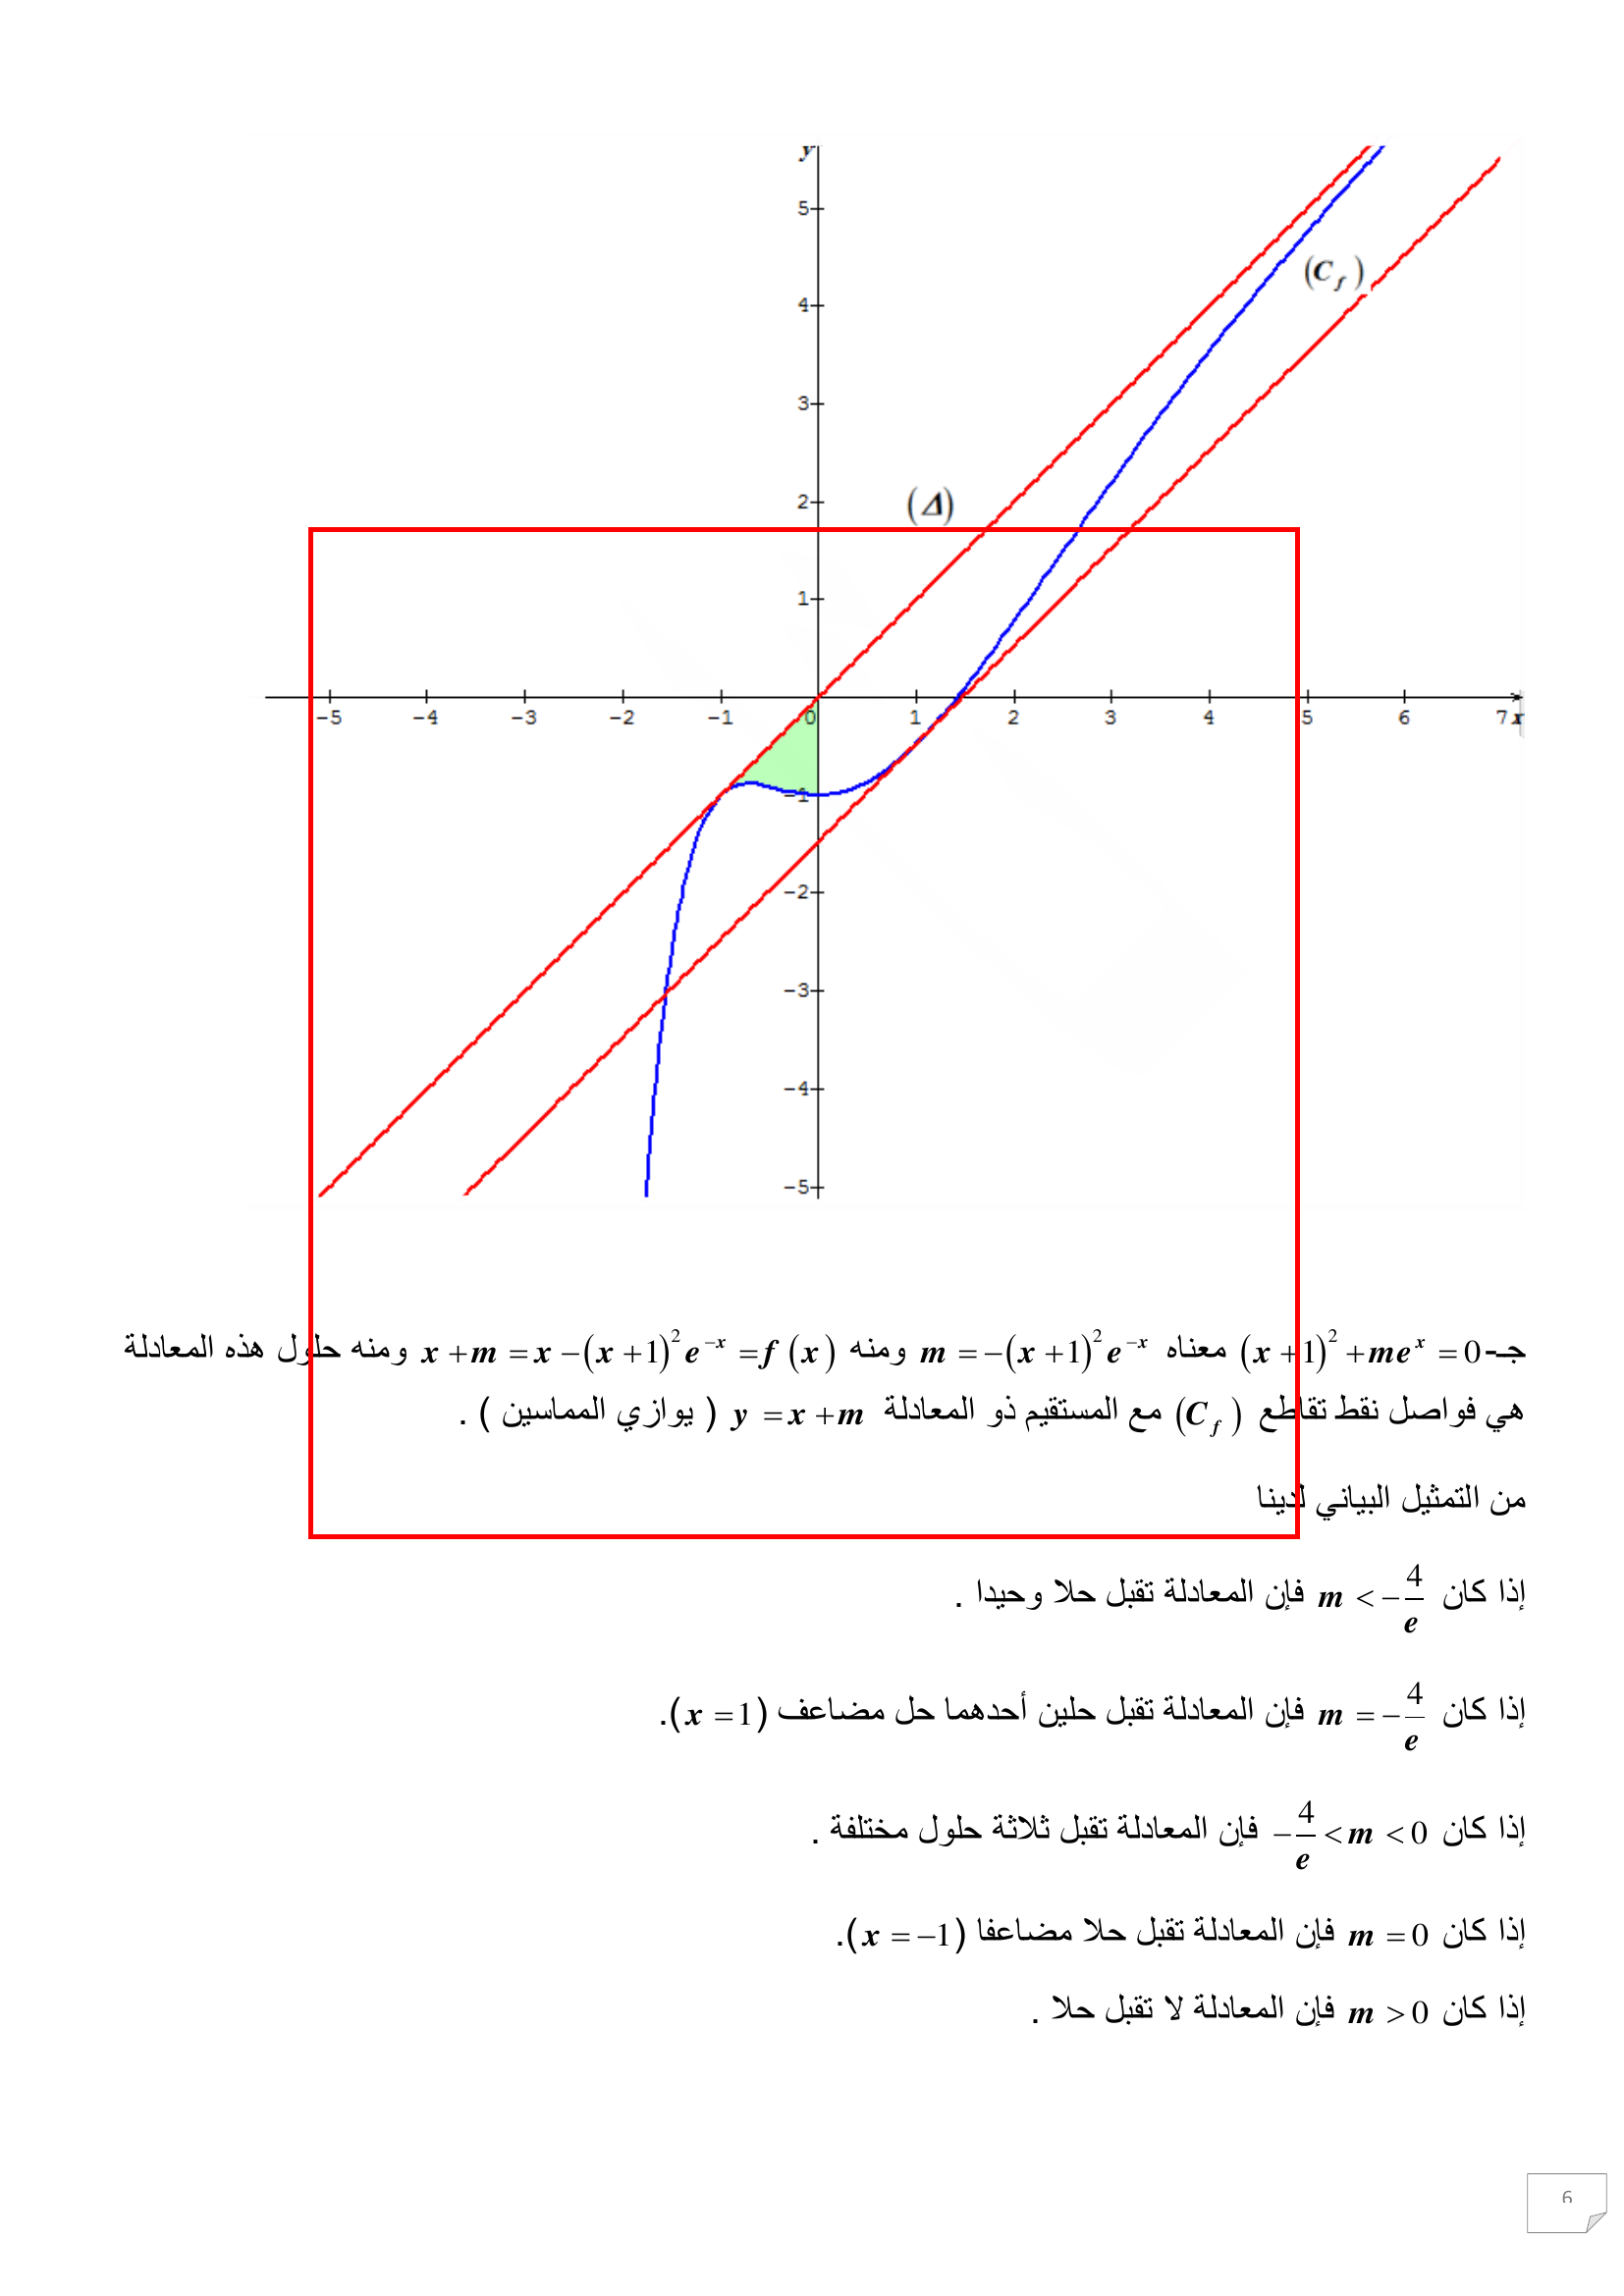

Displaying 1 figure(s) from 2021.pdf, Page 4


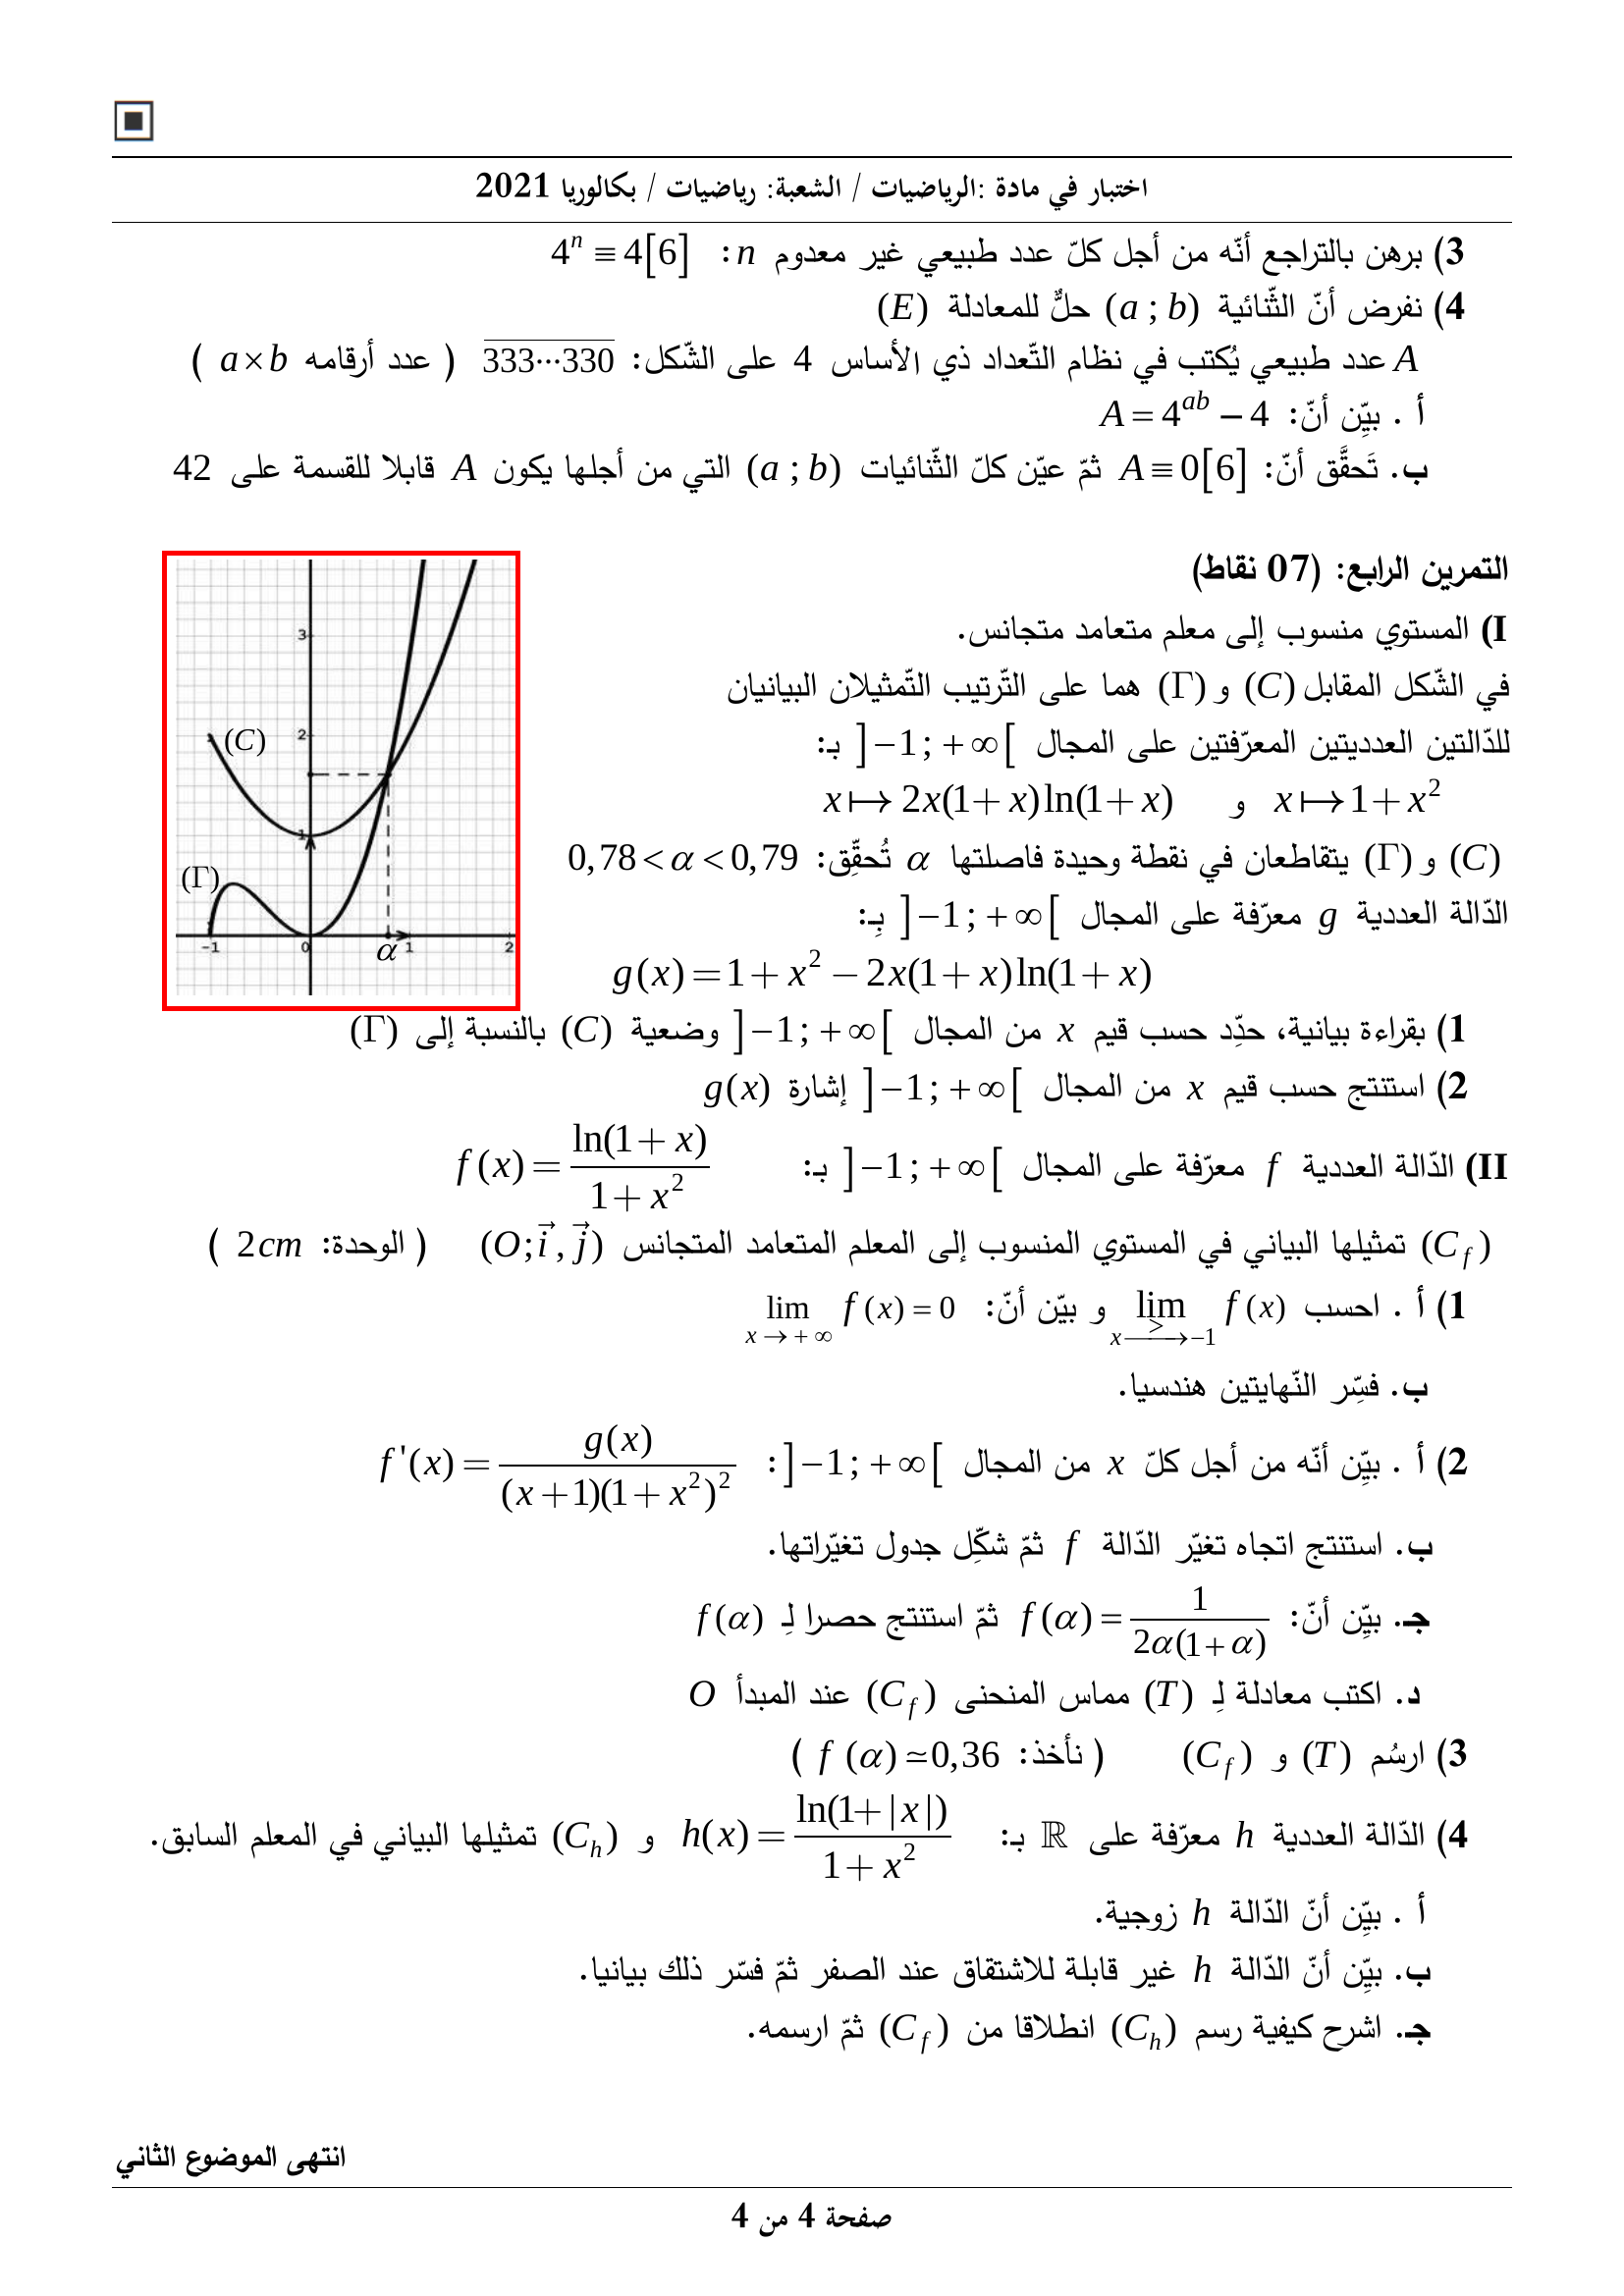

Displaying 1 figure(s) from 2021.pdf, Page 7


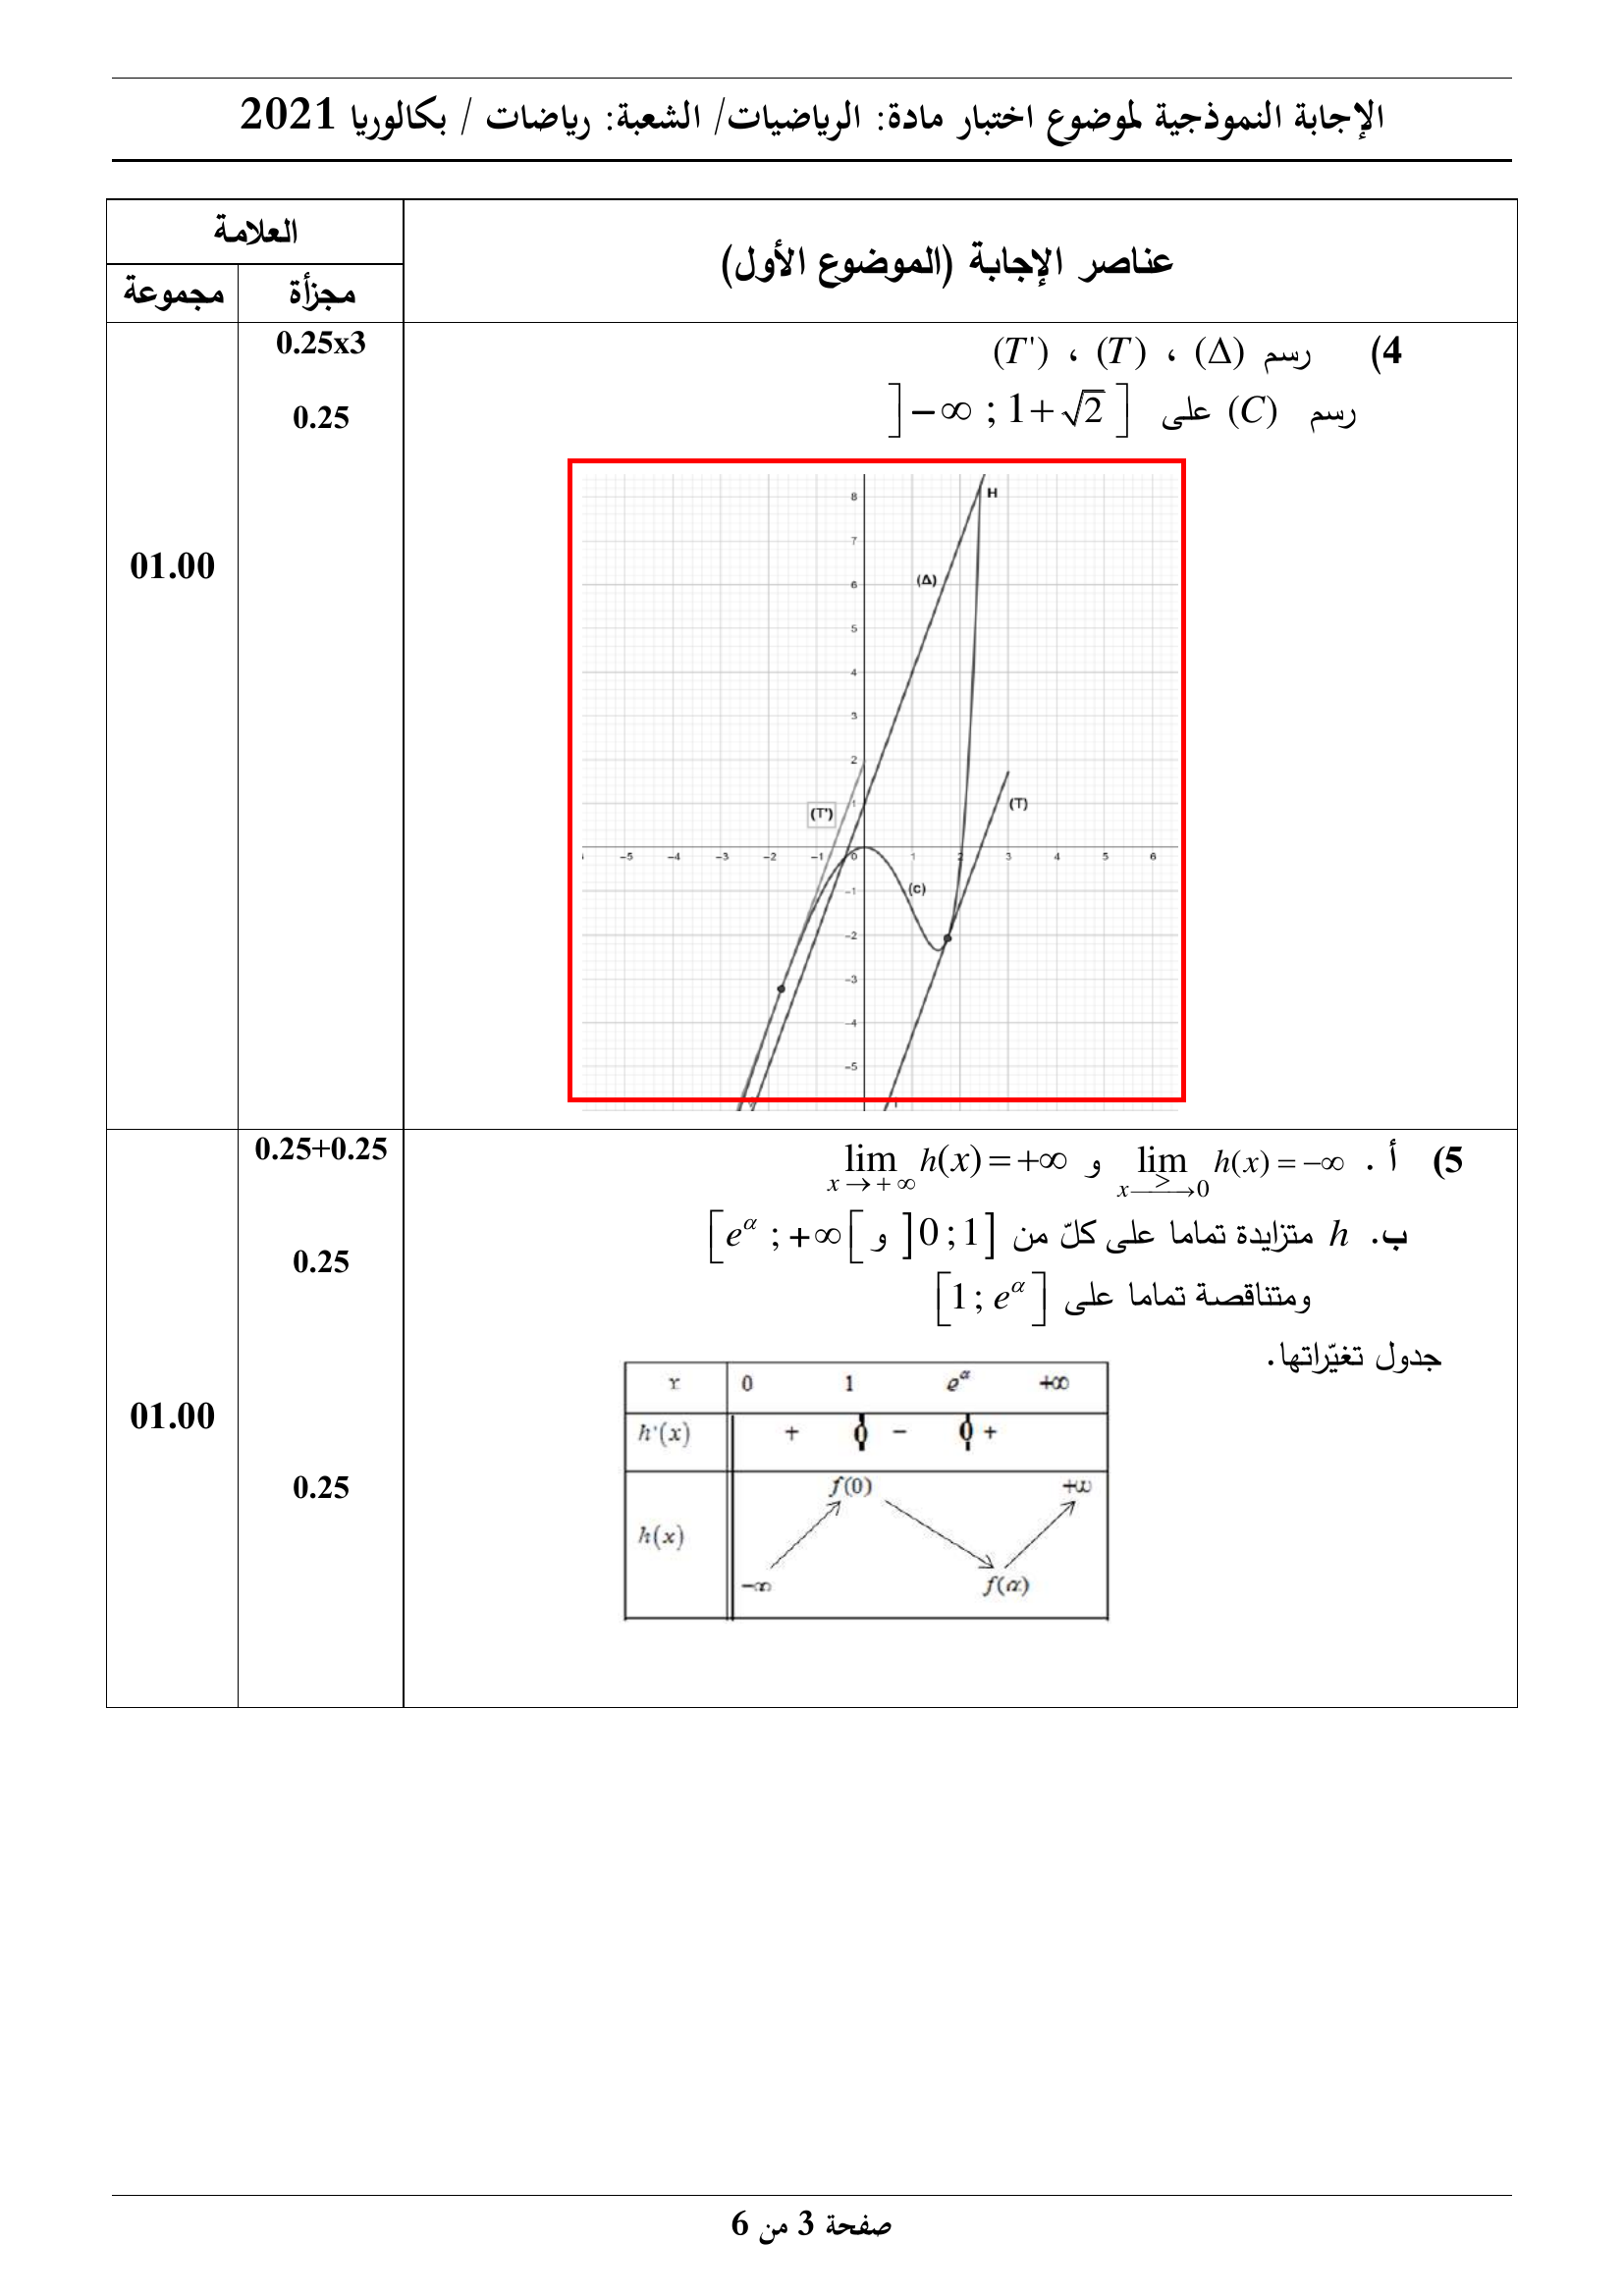

In [6]:
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
from IPython.display import display
from collections import defaultdict

JSON_DIR = Path("../data/dzexams/maths/bac/bac-results")
PDF_DIR = Path("../data/dzexams/maths/bac/bac-sujets")

# Group figures by (source_file, source_page) to draw multiple boxes on the same page
figures_by_page = defaultdict(list)

for json_file in JSON_DIR.glob("*.json"):
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    figures = data.get('figures', [])
    for fig in figures:
        bbox = fig.get('bounding_box')
        source_page = fig.get('source_page')
        
        if bbox and source_page is not None:
            source_file = data.get('exam_metadata', {}).get('source_file')
            if source_file:
                figures_by_page[(source_file, source_page)].append(bbox)

# Display just the first few pages that have figures so it doesn't flood the notebook
display_limit = 8
displayed = 0

for (source_file, source_page), bboxes in figures_by_page.items():
    if displayed >= display_limit:
        break
        
    pdf_path = PDF_DIR / source_file
    if pdf_path.exists():
        print(f"Displaying {len(bboxes)} figure(s) from {pdf_path.name}, Page {source_page}")
        
        images = convert_from_path(pdf_path, first_page=source_page, last_page=source_page)
        if images:
            img = images[0]
            draw = ImageDraw.Draw(img)
            width, height = img.size
            
            # Draw all bounding boxes for this page
            for bbox in bboxes:
                ymin, xmin, ymax, xmax = bbox
                x0 = (xmin / 1000.0) * width
                y0 = (ymin / 1000.0) * height
                x1 = (xmax / 1000.0) * width
                y1 = (ymax / 1000.0) * height
                
                draw.rectangle([x0, y0, x1, y1], outline="red", width=5)
                
            display(img)
            displayed += 1